In [1]:
import os
import numpy as np
import torch 
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.data import Dataset
from torchvision import datasets, transforms
from matplotlib import pyplot as plt
import glob
import random
import torch.nn as nn
from torchsummary import summary
import torch.nn.functional as F
import gc

In [2]:
import os
from torchvision.io import read_image
import numpy as np

class CustomImageDataset(Dataset):
    def __init__(self, pat_name, img_dir,label_dir):
        self.img_names = pat_name
        self.img_dir = img_dir
        self.label_dir = label_dir

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_names[idx])
        #print(img_path)
        label_path = os.path.join(self.label_dir, self.img_names[idx])
        image = np.load(img_path)
        image = image.astype('float32')
        image = np.transpose(image,(3,2,0,1))
        image= torch.from_numpy(image)
        # image = image[1,:,:,:]
        # image = image.unsqueeze(0)
        #image = image.type(torch.LongTensor)
        #image=image.to('cuda')
        #image=transform(image)
        label = np.load(label_path)
        label = label.astype('float32') 
        label = np.transpose(label,(2,0,1))
        label= torch.from_numpy(label)
        #label = label.type(torch.LongTensor)
        #label=label.to('cuda')
        #label=transform(label)
        return image, label

In [3]:
img_path="../fdg/train_image/"
label_path="../fdg/train_label/"
img_list=os.listdir(img_path)
training_data=CustomImageDataset(img_list,img_path,label_path)

In [4]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=2, shuffle=True)

In [5]:
dataiter = iter(train_dataloader)
images, labels = dataiter.__next__()
print(type(images))
print(images.shape)
print(labels.shape)
print(torch.unique(labels[0,:,:,:]))
print(torch.unique(labels[1,:,:,:]))

<class 'torch.Tensor'>
torch.Size([2, 2, 16, 400, 400])
torch.Size([2, 16, 400, 400])
tensor([0., 1.])
tensor([0.])


13


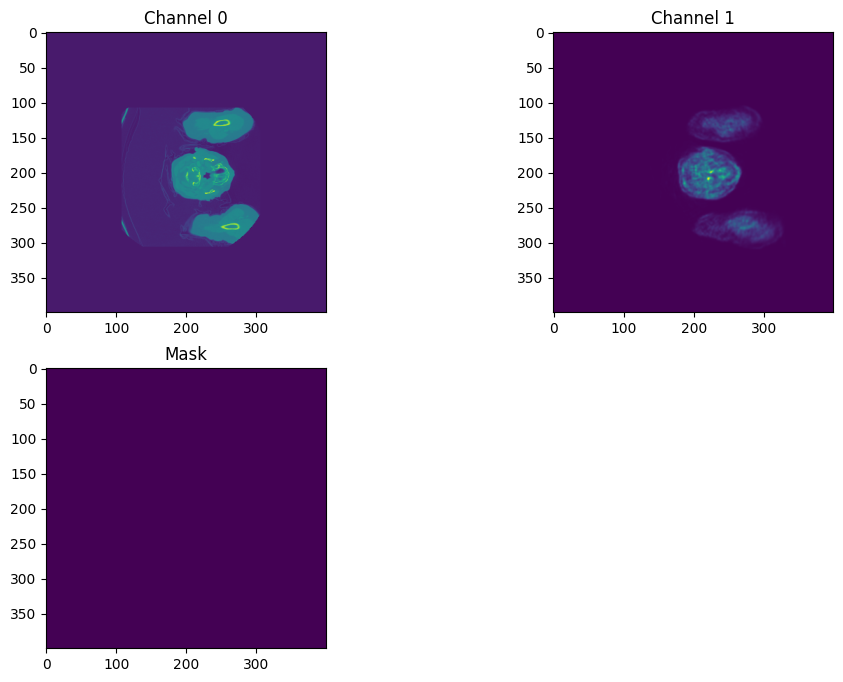

In [6]:
#batch = random.randint(0,1)
batch=0
#n_slice = random.randint(arr_0[0],arr_0[-1])
n_slice = random.randint(0,15)
a = images[batch,:,n_slice,:,:]
# a=a.cpu()
print(n_slice)
plt.figure(figsize=(12, 8))
plt.subplot(221)
plt.imshow(a[0])
plt.title('Channel 0')
plt.subplot(222)
plt.imshow(a[1])
plt.title('Channel 1')
plt.subplot(223)
plt.imshow(labels[batch,n_slice,:,:])
plt.title('Mask')
plt.show()

In [7]:
def window_partition_3d(x, window_size):
    B, C, D, H, W = x.shape
    x = x.view(B, C,
               D // window_size, window_size,
               H // window_size, window_size,
               W // window_size, window_size)
    x = x.permute(0, 2, 4, 6, 1, 3, 5, 7).contiguous()
    return x.view(-1, C, window_size, window_size, window_size)

In [8]:
def window_reverse_3d(windows, window_size, B, D, H, W):
    C = windows.shape[1]
    x = windows.view(B,
                     D // window_size,
                     H // window_size,
                     W // window_size,
                     C,
                     window_size,
                     window_size,
                     window_size)
    x = x.permute(0, 4, 1, 5, 2, 6, 3, 7).contiguous()
    return x.view(B, C, D, H, W)

In [9]:
class WindowAttention3D(nn.Module):
    def __init__(self, dim, window_size, num_heads):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads

        self.qkv = nn.Linear(dim, dim * 3)
        self.attn_drop = nn.Dropout(0.1)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B_, C, D, H, W = x.shape
        x = x.view(B_, C, -1).transpose(1, 2)  # (B_, N, C)
        qkv = self.qkv(x).chunk(3, dim=-1)
        q, k, v = [x.view(B_, -1, self.num_heads, C // self.num_heads).transpose(1, 2) for x in qkv]

        attn = (q @ k.transpose(-2, -1)) * (1.0 / (C // self.num_heads)**0.5)
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B_, -1, C)
        x = self.proj(x)
        return x.transpose(1, 2).view(B_, C, D, H, W)

In [10]:
class SwinBlock3D(nn.Module):
    def __init__(self, dim, window_size=4, shift=False, num_heads=4):
        super().__init__()
        self.window_size = window_size
        self.shift = shift
        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention3D(dim, window_size, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, x):
        B, C, D, H, W = x.shape
        shortcut = x

        if self.shift:
            x = torch.roll(x, shifts=(-self.window_size // 2,) * 3, dims=(2, 3, 4))

        windows = window_partition_3d(x, self.window_size)
        attn_windows = self.attn(windows)
        x = window_reverse_3d(attn_windows, self.window_size, B, D, H, W)

        if self.shift:
            x = torch.roll(x, shifts=(self.window_size // 2,) * 3, dims=(2, 3, 4))

        x = x + shortcut
        x = x.flatten(2).transpose(1, 2)
        x = x + self.mlp(self.norm2(x))
        x = x.transpose(1, 2).view(B, C, D, H, W)
        return x

In [11]:
class PatchEmbedding3D(nn.Module):
    def __init__(self, in_channels, embed_dim, patch_size):
        super().__init__()
        self.proj = nn.Conv3d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x)

In [12]:
class DownsampleBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv3d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        return self.conv(x)

class UpsampleBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        return self.up(x)

In [13]:
class SwinUNet3D(nn.Module):
    def __init__(self, in_channels=2, num_classes=1, base_dim=32, window_size=2):
        super().__init__()
        self.patch_embed = PatchEmbedding3D(in_channels, base_dim, patch_size=2)

        self.encoder1 = nn.Sequential(
            SwinBlock3D(base_dim, window_size, shift=False),
            SwinBlock3D(base_dim, window_size, shift=True)
        )
        self.down1 = DownsampleBlock3D(base_dim, base_dim * 2)

        self.encoder2 = nn.Sequential(
            SwinBlock3D(base_dim * 2, window_size, shift=False),
            SwinBlock3D(base_dim * 2, window_size, shift=True)
        )
        self.down2 = DownsampleBlock3D(base_dim * 2, base_dim * 4)

        self.bottleneck = nn.Sequential(
            SwinBlock3D(base_dim * 4, window_size, shift=False),
            SwinBlock3D(base_dim * 4, window_size, shift=True)
        )

        self.up2 = UpsampleBlock3D(base_dim * 4, base_dim * 2)
        self.decoder2 = nn.Sequential(
            SwinBlock3D(base_dim * 2, window_size, shift=False),
            SwinBlock3D(base_dim * 2, window_size, shift=True)
        )

        self.up1 = UpsampleBlock3D(base_dim * 2, base_dim)
        self.decoder1 = nn.Sequential(
            SwinBlock3D(base_dim, window_size, shift=False),
            SwinBlock3D(base_dim, window_size, shift=True)
        )

        self.seg_head = nn.Conv3d(base_dim, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1 = self.patch_embed(x)  # [B, base_dim, D/2, H/2, W/2]
        e1 = self.encoder1(x1)
        e2 = self.encoder2(self.down1(e1))

        # Bottleneck
        b = self.bottleneck(self.down2(e2))

        # Decoder
        d2 = self.up2(b) + e2
        d2 = self.decoder2(d2)

        d1 = self.up1(d2) + e1
        d1 = self.decoder1(d1)

        return self.seg_head(d1)

In [14]:
model = SwinUNet3D(in_channels=2, num_classes=1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model = model.to(device)
summary(model, input_size=(2, 16, 400, 400))

cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv3d-1      [-1, 32, 8, 200, 200]             544
  PatchEmbedding3D-2      [-1, 32, 8, 200, 200]               0
            Linear-3                [-1, 8, 96]           3,168
           Dropout-4              [-1, 4, 8, 8]               0
            Linear-5                [-1, 8, 32]           1,056
 WindowAttention3D-6          [-1, 32, 2, 2, 2]               0
         LayerNorm-7           [-1, 320000, 32]              64
            Linear-8          [-1, 320000, 128]           4,224
              GELU-9          [-1, 320000, 128]               0
           Linear-10           [-1, 320000, 32]           4,128
      SwinBlock3D-11      [-1, 32, 8, 200, 200]               0
           Linear-12                [-1, 8, 96]           3,168
          Dropout-13              [-1, 4, 8, 8]               0
           Linear-14              

In [16]:
img_path="../fdg/train_image/"
label_path="../fdg/train_label/"
img_list=os.listdir(img_path)
training_data=CustomImageDataset(img_list,img_path,label_path)
val_img_path="../fdg/val_image/"
val_label_path="../fdg/val_label/"
val_img_list=os.listdir(val_img_path)
val_data=CustomImageDataset(val_img_list,val_img_path,val_label_path)

In [17]:
train_dataloader = DataLoader(training_data, batch_size=2, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=2, shuffle=True)
dataiter = iter(train_dataloader)
val_dataiter = iter(val_dataloader)
images, labels = dataiter.__next__()
val_images, val_labels = val_dataiter.__next__()
#print(val_labels.shape)

In [18]:
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2, reduction='mean'):
        super(BinaryFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs: (B, 1, D, H, W) logits
        # targets: (B, 1, D, H, W) or (B, D, H, W) with binary labels (0 or 1)
       
        inputs = inputs.view(-1)
        targets = targets.view(-1).float()
       
        probs = torch.sigmoid(inputs)
        pt = torch.where(targets == 1, probs, 1 - probs)
        log_pt = torch.log(pt + 1e-8)
        loss = -self.alpha * (1 - pt) ** self.gamma * log_pt

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

In [19]:
class DiceLoss(nn.Module):
    def __init__(self, eps=1e-15):
        super().__init__()
        self.eps = eps
        
    def forward(self, y_pred, y_true):

        dice_coef = 0.
        
        intersection = y_true[:].float() * y_pred[:].float()
        union = y_true[:].float() + y_pred[:].float()
        
        dice_coef += ((2*intersection.sum() + self.eps)/(union.sum()+self.eps))
        return 1.-dice_coef

In [20]:
def apply_threshold_iou(output, threshold=1):
    return torch.where(output >= threshold, 1, output)

In [21]:
class IoU(nn.Module):
    def __init__(self, eps=1e-15):
        super().__init__()
        self.eps = eps
        
    def forward(self, y_pred, y_true):

        iou = 0.
        y_true=y_true.detach()
        y_pred=y_pred.detach()
        
        intersection = y_true[:].float() * y_pred[:].float()
        union = y_true[:].float() + y_pred[:].float()
        union = apply_threshold_iou(union)
        iou += ((intersection.sum() + self.eps)/(union.sum()+self.eps))
        return iou

In [22]:
import torch.optim as optim
criterion_ = DiceLoss()
criterion = BinaryFocalLoss(alpha=0.25, gamma=2.0)
jaccard=IoU()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [23]:
def apply_threshold(output, threshold):
    return torch.where(output >= threshold, 1, 0)

In [24]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [26]:
import csv

In [25]:
file_path = '../fdg/stats/train_fdg_swin_2.csv'

In [ ]:

data = [['Epoch', 'Train_BFLoss', 'Training_Diceloss', 'Val_BFLoss', 'Val_Diceloss', 'IoU']]


with open(file_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(data)

In [28]:
val_history=0.0433217
iou_history=0.74994836
save_epoch = 3

In [29]:
early_stopper = EarlyStopper(patience=10, min_delta=0)


for epoch in range(3,100):
    print(f"EPOCH\n{epoch}\n********************************")
    running_loss = 0.0
    running_dice = 0.0
    total_val_loss = 0.0
    total_val_dice = 0.0
    total_iou = 0.0
    training_loss = 0.0
    training_dice = 0.0

    # Training phase
    model.train()
    for i, data in enumerate(train_dataloader, 0):
        inputs, labels = data
        inputs = inputs.cuda(non_blocking=True)
        labels = labels.cuda(non_blocking=True)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs=outputs.squeeze(1)
        outputs = F.interpolate(outputs.float().unsqueeze(1), size=(16, 400, 400), mode='trilinear')
        
        loss = criterion(outputs, labels)
        dice = criterion_(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        training_loss += loss.item()
        running_dice += dice.item()
        training_dice += dice.item()

        # Cleanup
        del inputs, labels, outputs, loss
        torch.cuda.empty_cache()
        print(i)
        if i % 100 == 99:
            print(f"RUNNING LOSS\n[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 100:.3f} dice: {running_dice / 100:.3f}")
            running_loss = 0.0
            running_dice = 0.0

    avg_train_loss = training_loss / len(train_dataloader)
    avg_train_dice = training_dice / len(train_dataloader)
    print(f"TRAINING LOSS\n[{epoch + 1}] training_loss: {avg_train_loss:.3f}")
    print(f"TRAINING DICE LOSS\n[{epoch + 1}] training_dice: {avg_train_dice:.3f}")

    # Validation phase
    model.eval()
    total_val_loss = 0.0
    total_val_dice = 0.0
    total_iou = 0.0

    with torch.no_grad():  # Critical: No gradients during validation
        for j, val_data in enumerate(val_dataloader):
            val_inputs, val_labels = val_data
            val_inputs = val_inputs.cuda(non_blocking=True)
            val_labels = val_labels.cuda(non_blocking=True)
            
            val_outputs = model(val_inputs)
            val_outputs = val_outputs.squeeze(1)
            val_outputs = F.interpolate(val_outputs.float().unsqueeze(1), size=(16, 400, 400), mode='trilinear')
            val_outputs = apply_threshold(val_outputs, 0.5)
            
            val_loss = criterion(val_outputs, val_labels)
            val_dice = criterion_(val_outputs, val_labels)
            iou = jaccard(val_outputs, val_labels)
            
            total_val_loss += val_loss.item()
            total_val_dice += val_dice.item()
            total_iou += iou.item()

            # Cleanup
            del val_inputs, val_labels, val_outputs, val_loss, iou
            torch.cuda.empty_cache()

    avg_val_loss = total_val_loss / len(val_dataloader)
    avg_val_dice = total_val_dice / len(val_dataloader)
    avg_iou = total_iou / len(val_dataloader)
    
    print(f"IOU SCORE: {avg_iou:.3f}\nPREVIOUS: {iou_history:.3f}")
    print(f"VALIDATION LOSS: {avg_val_loss:.3f}\nPREVIOUS: {val_history:.3f}")
    print(f"VALIDATION DICE LOSS: {avg_val_dice:.3f}")

    # Save results to CSV
    new_data = [[epoch+1, avg_train_loss, avg_train_dice, avg_val_loss, avg_val_dice, avg_iou]]
    with open(file_path, 'a', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerows(new_data)
    
    # Early stopping check
    if early_stopper.early_stop(avg_val_loss):
        print("SATURATION POINT REACHED")
        break

    # Save best model
    if avg_iou >= iou_history:
        iou_history = avg_iou
        val_history = avg_val_loss
        save_epoch = epoch + 1
        torch.save(model.state_dict(), "../fdg/weights/train_fdg_swin_2.pt")
        print("WEIGHTS SAVED")

print('Finished Training')
print(save_epoch)

EPOCH
3
********************************
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
RUNNING LOSS
[4,   100] loss: 0.000 dice: 1.000
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
RUNNING LOSS
[4,   200] loss: 0.000 dice: 1.000
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
2

KeyboardInterrupt: 

In [30]:
torch.save(model.state_dict(), "../fdg/weights/train_fdg_swin_2_temp.pt")

In [15]:
model.load_state_dict(torch.load('../fdg/weights/train_fdg_swin_2.pt'))
model.eval()

SwinUNet3D(
  (patch_embed): PatchEmbedding3D(
    (proj): Conv3d(2, 32, kernel_size=(2, 2, 2), stride=(2, 2, 2))
  )
  (encoder1): Sequential(
    (0): SwinBlock3D(
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (attn): WindowAttention3D(
        (qkv): Linear(in_features=32, out_features=96, bias=True)
        (attn_drop): Dropout(p=0.1, inplace=False)
        (proj): Linear(in_features=32, out_features=32, bias=True)
      )
      (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=32, out_features=128, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (1): SwinBlock3D(
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (attn): WindowAttention3D(
        (qkv): Linear(in_features=32, out_features=96, bias=True)
        (attn_drop): Dropout(p=0.1, inplace=False)
        (proj): Linear(in_

In [47]:
val_img_path="../fdg/val_image/"
val_label_path="../fdg/val_label/"
val_img_list=os.listdir(val_img_path)
val_data=CustomImageDataset(val_img_list,val_img_path,val_label_path)

In [358]:
val_dataloader = DataLoader(val_data, batch_size=2, shuffle=True)
val_dataiter = iter(val_dataloader)
val_images_t, val_labels_t = val_dataiter.__next__()
print(torch.unique(val_labels_t[0,:,:,:]))
print(torch.unique(val_labels_t[1,:,:,:]))

tensor([0., 1.])
tensor([0.])


In [359]:
val_images=val_images_t.cuda()
val_output=model(val_images)
val_output = val_output.squeeze(1)
val_output = F.interpolate(val_output.float().unsqueeze(1), size=(16, 400, 400), mode='trilinear')
val_output = val_output.squeeze(1)
val_threshold_output= apply_threshold(val_output,0.0001)
val_output=val_output.cpu()
val_threshold_output=val_threshold_output.cpu()
val_output=val_output.detach()
val_images=val_images.cpu()

In [360]:
channel=0

In [361]:
print(val_output.shape)

torch.Size([2, 16, 400, 400])


Text(0.5, 1.0, 'Threshold Prediction')

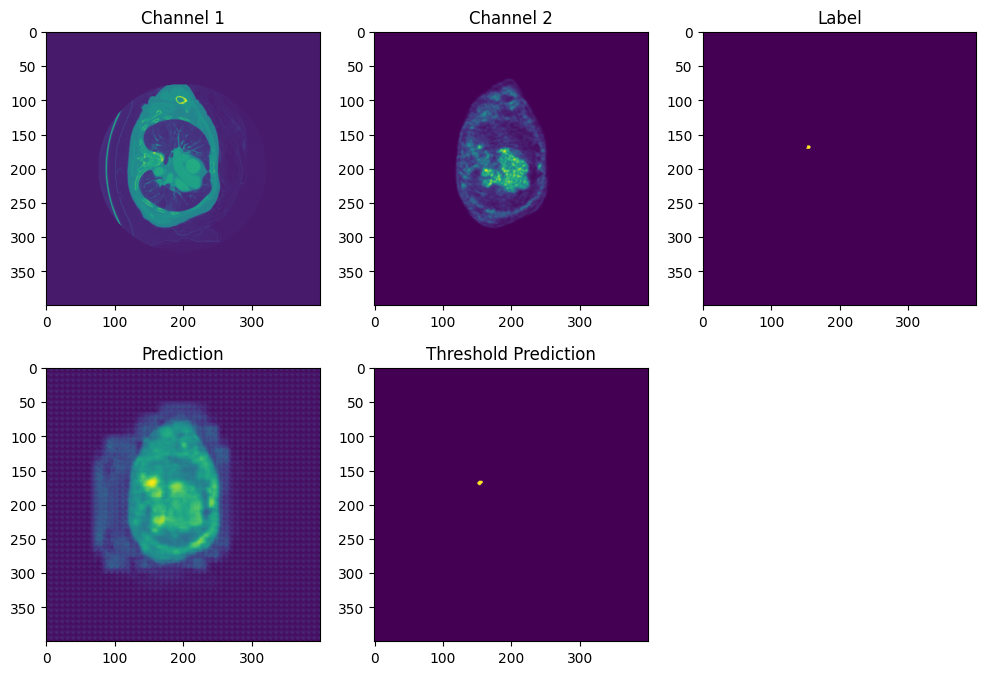

In [365]:
slide=random.randint(0,15)
plt.figure(figsize=(12, 8))
plt.subplot(231)
plt.imshow(val_images[channel,0,slide,:,:])
plt.title('Channel 1')
plt.subplot(232)
plt.imshow(val_images[channel,1,slide,:,:])
plt.title('Channel 2')
plt.subplot(233)
plt.imshow(val_labels_t[channel,slide,:,:])
plt.title('Label')
plt.subplot(234)
plt.imshow(val_output[channel,slide,:,:])
plt.title('Prediction')
plt.subplot(235)

plt.imshow(val_threshold_output[channel,slide,:,:])
plt.title('Threshold Prediction')